# Model Comparison & Statistical Analysis
**Goal:** Demonstrate that performance ceiling is a data/distribution issue, not a model capacity issue.

All 8 models are evaluated under identical conditions:
- **Temporal:** Train on `trainval`, evaluate on `test`
- **Spatial:** LOSO over the 5 WA stations in `trainval`

No hyperparameter tuning beyond light defaults. Speed over performance.

**Author:** Jakob Balkovec

## 0. Imports & Setup

In [1]:
import os
import sys
import random
import warnings
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('imports loaded')

imports loaded


## 1. Paths & Data Loading

In [2]:
VERSION      = 'v1.3'
SUBVERSION   = 'v1.3'

PROJECT_ROOT = '/Users/jbalkovec/Desktop/MDR'
DATA_ROOT    = f'{PROJECT_ROOT}/Temporal/Pipeline/data'
SPLIT_ROOT   = f'{DATA_ROOT}/splits'
OUTPUT_ROOT  = f'{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}/comparison'

os.makedirs(OUTPUT_ROOT, exist_ok=True)

TRAIN_PATH = str(Path(SPLIT_ROOT) / 'derived_8.0/train.csv')
VAL_PATH   = str(Path(SPLIT_ROOT) / 'derived_8.0/val.csv')
TEST_PATH  = str(Path(SPLIT_ROOT) / 'derived_8.0/test.csv')

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Missing split file: {p}')

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
trainval_df['date'] = pd.to_datetime(trainval_df['date'], errors='coerce')
trainval_df['year'] = trainval_df['date'].dt.year.astype(float)

print(f'trainval: {trainval_df.shape}  |  test: {test_df.shape}')
print(f'stations in trainval: {sorted(trainval_df.station_id.unique())}')
print(f'stations in test:     {sorted(test_df.station_id.unique())}')

trainval: (9588, 499)  |  test: (4016, 499)
stations in trainval: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
stations in test:     ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']


## 2. Feature Columns & Utilities

In [3]:
TARGET_COL = 'soil_moisture_5cm'

FEATURE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
]


def assign_regime(sm):
    if sm < 0.20:
        return 'Dry'
    elif sm < 0.313:
        return 'Transition'
    else:
        return 'Wet'


def get_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err    = y_true - y_pred
    bias   = float(np.mean(err))
    rmse_v = float(np.sqrt(np.mean(err ** 2)))
    return {
        'n':       int(len(y_true)),
        'r2':      float(r2_score(y_true, y_pred)),
        'mae':     float(mean_absolute_error(y_true, y_pred)),
        'rmse':    rmse_v,
        'ubrmse':  float(np.std(err)),
        'bias':    bias,
        'q90_ae':  float(np.quantile(np.abs(err), 0.90)),
    }


# Combined temporal + regime sample weights (same as v1.3 notebook)
max_year  = trainval_df['year'].max()
w_temporal = np.exp(0.2 * (trainval_df['year'] - max_year))
w_temporal = w_temporal / w_temporal.mean()

trainval_df['regime'] = trainval_df[TARGET_COL].apply(assign_regime)
regime_counts  = trainval_df['regime'].value_counts()
regime_weights = (1.0 / regime_counts) / (1.0 / regime_counts).sum()
w_regime       = trainval_df['regime'].map(regime_weights)

w_combined = w_temporal * w_regime
w_combined = w_combined / w_combined.mean()

print('sample weights ready')
print(f'weight range: [{w_combined.min():.3f}, {w_combined.max():.3f}]')

sample weights ready
weight range: [0.435, 3.431]


## 3. Model Registry

Light defaults only — speed over performance. SVR and KNN use a scaler pipeline since they are not scale-invariant. Combined sample weights are passed where supported (XGBoost, RF, LightGBM, CatBoost, GB, DT). SVR and KNN do not support `sample_weight` natively.

In [8]:
valid_mask = trainval_df[FEATURE_COLS + [TARGET_COL]].notna().all(axis=1)
trainval_df = trainval_df[valid_mask].reset_index(drop=True)

max_year  = trainval_df['year'].max()
w_temporal = np.exp(0.2 * (trainval_df['year'] - max_year))
w_temporal = w_temporal / w_temporal.mean()

trainval_df['regime'] = trainval_df[TARGET_COL].apply(assign_regime)
regime_counts  = trainval_df['regime'].value_counts()
regime_weights = (1.0 / regime_counts) / (1.0 / regime_counts).sum()
w_regime       = trainval_df['regime'].map(regime_weights)

w_combined = w_temporal * w_regime
w_combined = w_combined / w_combined.mean()

test_valid_mask = test_df[FEATURE_COLS + [TARGET_COL]].notna().all(axis=1)
test_df = test_df[test_valid_mask].reset_index(drop=True)

print(f'After NaN removal: trainval {trainval_df.shape}, test {test_df.shape}')

X_trainval = trainval_df[FEATURE_COLS].values
y_trainval = trainval_df[TARGET_COL].values
w_trainval = w_combined.values

X_test = test_df[FEATURE_COLS].values
y_test = test_df[TARGET_COL].values

STATIONS = sorted(trainval_df['station_id'].unique())
print(f'LOSO stations: {STATIONS}')


MODEL_REGISTRY = [
    (
        'XGBoost',
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.5,
            reg_alpha=0.03,
            objective='reg:squarederror',
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        ),
        True,
    ),
    (
        'RandomForest',
        RandomForestRegressor(
            n_estimators=500,
            max_depth=20,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=SEED,
            n_jobs=-1,
        ),
        True,
    ),
    (
        'LightGBM',
        lgb.LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        ),
        True,
    ),
    (
        'CatBoost',
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=7,
            random_seed=SEED,
            verbose=0,
        ),
        True,
    ),
    (
        'GradientBoosting',
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            random_state=SEED,
        ),
        True,
    ),
    (
        'DecisionTree',
        DecisionTreeRegressor(
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=SEED,
        ),
        True,
    ),
    (
        'SVR',
        Pipeline([
            ('scaler', StandardScaler()),
            ('svr',    SVR(kernel='rbf', C=10.0, epsilon=0.01, cache_size=500)),
        ]),
        False,
    ),
    (
        'KNN',
        Pipeline([
            ('scaler', StandardScaler()),
            ('knn',    KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1)),
        ]),
        False,
    ),
]

print(f'{len(MODEL_REGISTRY)} models registered')

After NaN removal: trainval (8191, 500), test (3846, 499)
LOSO stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
8 models registered


## 4. Temporal Evaluation

In [9]:
temporal_rows = []

print(f"{'Model':<20} {'R^2':>7} {'MAE':>8} {'RMSE':>8} {'ubRMSE':>8} {'Bias':>8} {'Q90_AE':>8} {'Time(s)':>9}")
print('-' * 82)

for name, model, supports_sw in MODEL_REGISTRY:
    t0 = time()

    if supports_sw:
        model.fit(X_trainval, y_trainval, sample_weight=w_trainval)
    else:
        model.fit(X_trainval, y_trainval)

    y_pred  = model.predict(X_test)
    elapsed = time() - t0

    m = get_metrics(y_test, y_pred)
    temporal_rows.append({'model': name, **m, 'train_time_s': round(elapsed, 1)})

    print(
        f'{name:<20} {m["r2"]:>7.4f} {m["mae"]:>8.4f} {m["rmse"]:>8.4f} '
        f'{m["ubrmse"]:>8.4f} {m["bias"]:>+8.4f} {m["q90_ae"]:>8.4f} {elapsed:>9.1f}'
    )

temporal_df = pd.DataFrame(temporal_rows)
print(f'\ntemporal evaluation done ({len(temporal_df)} models)')

Model                    R^2      MAE     RMSE   ubRMSE     Bias   Q90_AE   Time(s)
----------------------------------------------------------------------------------
XGBoost               0.8215   0.0287   0.0406   0.0404  -0.0035   0.0639       1.3
RandomForest          0.8347   0.0285   0.0390   0.0390  -0.0011   0.0589       3.2
LightGBM              0.8134   0.0301   0.0415   0.0413  -0.0033   0.0643       3.6
CatBoost              0.8116   0.0307   0.0417   0.0412  -0.0062   0.0614       1.5
GradientBoosting      0.8056   0.0306   0.0423   0.0421  -0.0042   0.0663      17.3
DecisionTree          0.6764   0.0390   0.0546   0.0546  +0.0013   0.0969       0.1
SVR                   0.6747   0.0440   0.0547   0.0488  -0.0248   0.0910       3.4
KNN                   0.6685   0.0397   0.0553   0.0551  -0.0048   0.0909       0.1

temporal evaluation done (8 models)


## 5. Spatial Evaluation (LOSO)

In [10]:
spatial_rows = []

for name, model, supports_sw in MODEL_REGISTRY:
    print(f'\n--- {name} ---')

    for station in STATIONS:
        train_mask = trainval_df['station_id'] != station
        test_mask  = trainval_df['station_id'] == station

        X_tr = trainval_df.loc[train_mask, FEATURE_COLS].values
        y_tr = trainval_df.loc[train_mask, TARGET_COL].values
        w_tr = w_combined[train_mask].values

        X_te = trainval_df.loc[test_mask, FEATURE_COLS].values
        y_te = trainval_df.loc[test_mask, TARGET_COL].values

        t0 = time()
        if supports_sw:
            model.fit(X_tr, y_tr, sample_weight=w_tr)
        else:
            model.fit(X_tr, y_tr)

        y_pred  = model.predict(X_te)
        elapsed = time() - t0

        m = get_metrics(y_te, y_pred)
        spatial_rows.append({
            'model':   name,
            'station': station,
            **m,
            'train_time_s': round(elapsed, 1),
        })

        print(f'  {station:<30} R²={m["r2"]:+.4f}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}  [{elapsed:.1f}s]')

spatial_df = pd.DataFrame(spatial_rows)
print(f'\nspatial evaluation done — {len(spatial_df)} model × station combinations')


--- XGBoost ---
  Darrington                     R²=+0.6934  MAE=0.0501  RMSE=0.0602  [1.5s]
  Quinault                       R²=+0.2652  MAE=0.0537  RMSE=0.0632  [1.3s]
  SourdoughGulch_WA_985          R²=+0.5469  MAE=0.0536  RMSE=0.0683  [1.3s]
  Spokane                        R²=+0.6536  MAE=0.0530  RMSE=0.0637  [1.9s]

--- RandomForest ---
  Darrington                     R²=+0.7259  MAE=0.0472  RMSE=0.0569  [1.5s]
  Quinault                       R²=+0.1189  MAE=0.0593  RMSE=0.0692  [1.5s]
  SourdoughGulch_WA_985          R²=+0.5595  MAE=0.0542  RMSE=0.0674  [1.6s]
  Spokane                        R²=+0.7298  MAE=0.0481  RMSE=0.0563  [1.4s]

--- LightGBM ---
  Darrington                     R²=+0.7576  MAE=0.0445  RMSE=0.0535  [4.4s]
  Quinault                       R²=+0.2830  MAE=0.0530  RMSE=0.0624  [4.3s]
  SourdoughGulch_WA_985          R²=+0.5238  MAE=0.0547  RMSE=0.0700  [3.9s]
  Spokane                        R²=+0.6692  MAE=0.0524  RMSE=0.0623  [3.3s]

--- CatBoost ---
 

## 6. Summary DataFrame

- **Temporal metrics:** taken directly from test-set evaluation (no averaging needed)
- **Spatial metrics:** averaged across the 5 LOSO stations per model

In [11]:
METRIC_COLS = ['r2', 'mae', 'rmse', 'ubrmse', 'bias', 'q90_ae']

# Spatial: mean across stations per model
spatial_avg = (
    spatial_df
    .groupby('model')[METRIC_COLS]
    .mean()
    .reset_index()
    .rename(columns={c: f'spatial_{c}' for c in METRIC_COLS})
)

# Temporal: one row per model already
temporal_slim = temporal_df[['model'] + METRIC_COLS].copy()
temporal_slim = temporal_slim.rename(columns={c: f'temporal_{c}' for c in METRIC_COLS})

summary_df = temporal_slim.merge(spatial_avg, on='model')

# Reorder for readability: temporal cols then spatial cols
col_order = ['model'] + [f'temporal_{c}' for c in METRIC_COLS] + [f'spatial_{c}' for c in METRIC_COLS]
summary_df = summary_df[col_order].sort_values('temporal_r2', ascending=False).reset_index(drop=True)

print('=== SUMMARY TABLE ===')
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== SUMMARY TABLE ===
           model  temporal_r2  temporal_mae  temporal_rmse  temporal_ubrmse  temporal_bias  temporal_q90_ae  spatial_r2  spatial_mae  spatial_rmse  spatial_ubrmse  spatial_bias  spatial_q90_ae
    RandomForest       0.8347        0.0285         0.0390           0.0390        -0.0011           0.0589      0.5335       0.0522        0.0624          0.0532       -0.0056          0.0965
         XGBoost       0.8215        0.0287         0.0406           0.0404        -0.0035           0.0639      0.5398       0.0526        0.0639          0.0573       -0.0001          0.1001
        LightGBM       0.8134        0.0301         0.0415           0.0413        -0.0033           0.0643      0.5584       0.0512        0.0621          0.0563       -0.0045          0.0981
        CatBoost       0.8116        0.0307         0.0417           0.0412        -0.0062           0.0614      0.4972       0.0544        0.0662          0.0571       -0.0110          0.1041
GradientBoost

## 7. Export DataFrames

In [12]:
temporal_path = os.path.join(OUTPUT_ROOT, 'temporal_evaluation.csv')
spatial_path  = os.path.join(OUTPUT_ROOT, 'spatial_evaluation.csv')
summary_path  = os.path.join(OUTPUT_ROOT, 'summary_evaluation.csv')

temporal_df.to_csv(temporal_path, index=False)
spatial_df.to_csv(spatial_path,   index=False)
summary_df.to_csv(summary_path,   index=False)

print(f'temporal_evaluation.csv  -> {temporal_path}')
print(f'spatial_evaluation.csv   -> {spatial_path}')
print(f'summary_evaluation.csv   -> {summary_path}')

temporal_evaluation.csv  -> /Users/jbalkovec/Desktop/MDR/Models/Temporal/v1.3/v1.3/comparison/temporal_evaluation.csv
spatial_evaluation.csv   -> /Users/jbalkovec/Desktop/MDR/Models/Temporal/v1.3/v1.3/comparison/spatial_evaluation.csv
summary_evaluation.csv   -> /Users/jbalkovec/Desktop/MDR/Models/Temporal/v1.3/v1.3/comparison/summary_evaluation.csv


## 8. Statistical Analysis

This section is the core argument: if all models converge to a similar performance band, the bottleneck is the data, not the model.

### 8.1 R² Distribution Across Models

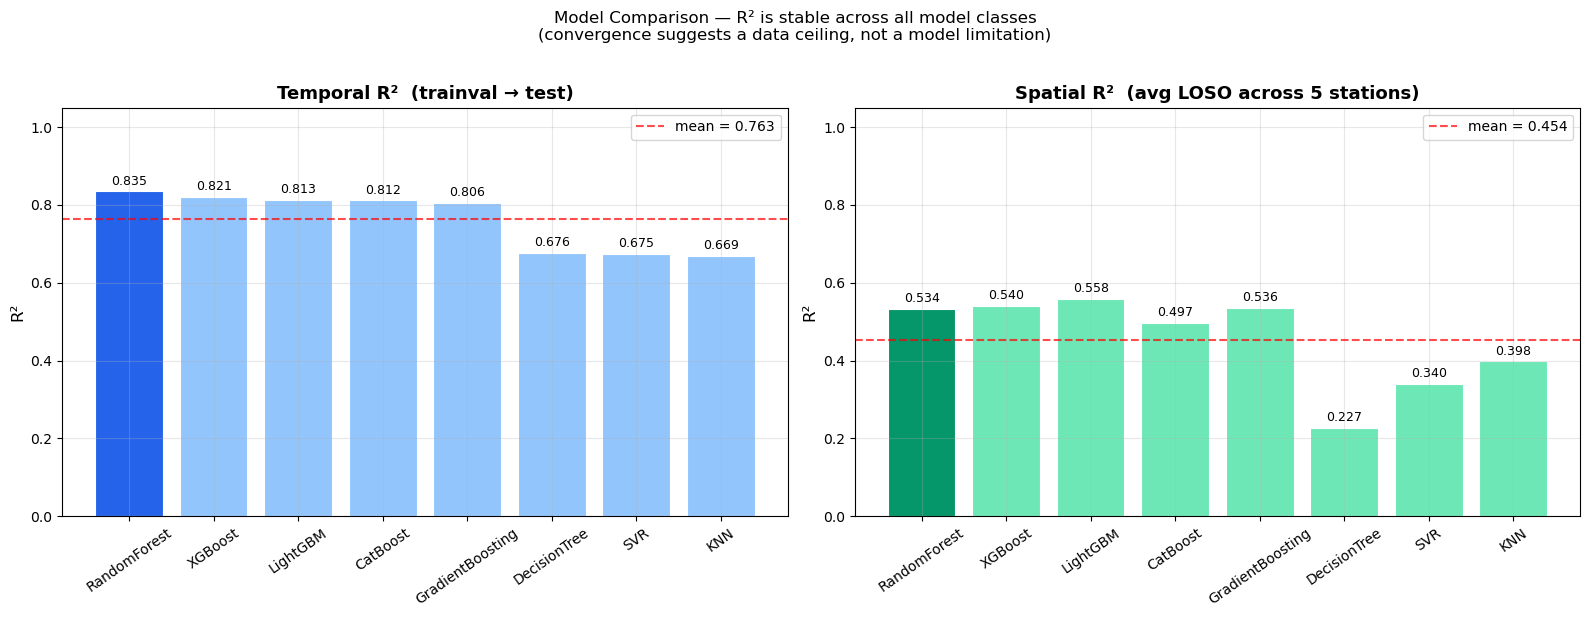

In [ ]:
model_order = summary_df.sort_values('temporal_r2', ascending=False)['model'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

temp_r2 = summary_df.set_index('model').loc[model_order, 'temporal_r2']
colors_t = ['#2563EB' if m == 'RandomForest' else '#93C5FD' for m in model_order]
bars = axes[0].bar(model_order, temp_r2, color=colors_t, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_title('Temporal R²  (trainval → test)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, temp_r2):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[0].axhline(temp_r2.mean(), color='red', linestyle='--', alpha=0.7, label=f'mean = {temp_r2.mean():.3f}')
axes[0].legend()

spat_r2  = summary_df.set_index('model').loc[model_order, 'spatial_r2']
colors_s = ['#059669' if m == 'RandomForest' else '#6EE7B7' for m in model_order]
bars2 = axes[1].bar(model_order, spat_r2, color=colors_s, edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].set_title('Spatial R²  (avg LOSO across 5 stations)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
for bar, val in zip(bars2, spat_r2):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].axhline(spat_r2.mean(), color='red', linestyle='--', alpha=0.7, label=f'mean = {spat_r2.mean():.3f}')
axes[1].legend()

plt.suptitle('Model Comparison: R^2 is stable across all model classes\n'
             '(convergence suggests a data ceiling, not a model limitation)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'r2_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Temporal Gap vs Spatial Gap Per Model

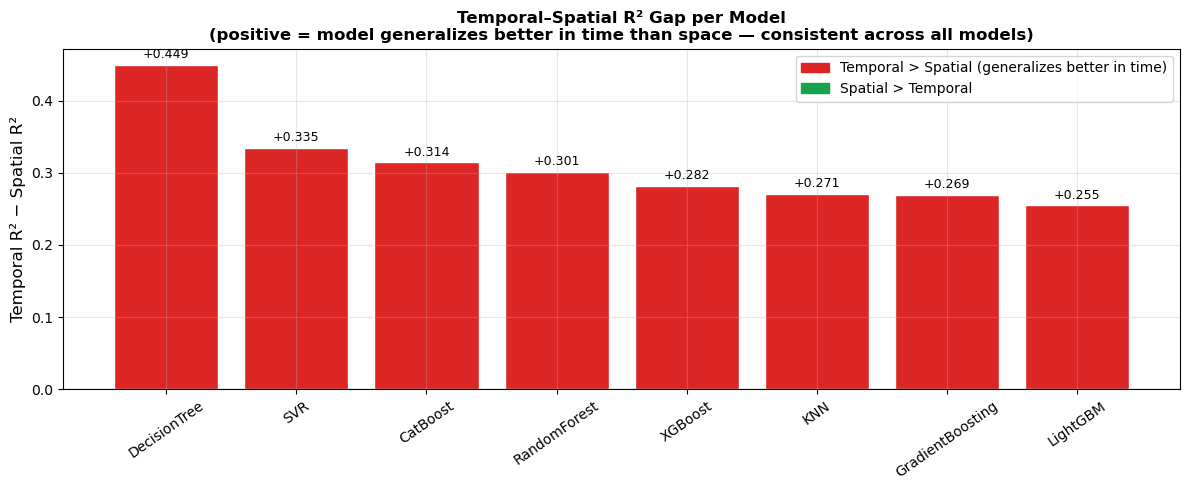

Mean temporal R²: 0.7633  std: 0.0751
Mean spatial R²:  0.4537  std: 0.1200
Mean gap:         0.3096


In [ ]:
summary_df['r2_gap'] = summary_df['temporal_r2'] - summary_df['spatial_r2']

fig, ax = plt.subplots(figsize=(12, 5))
gap_sorted = summary_df.sort_values('r2_gap', ascending=False)
colors_g = ['#DC2626' if g > 0 else '#16A34A' for g in gap_sorted['r2_gap']]
bars = ax.bar(gap_sorted['model'], gap_sorted['r2_gap'], color=colors_g, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Temporal R² - Spatial R²', fontsize=12)
ax.set_title('Temporal-Spatial R² Gap per Model\n'
             '(positive = model generalizes better in time than space — consistent across all models)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
for bar, val in zip(bars, gap_sorted['r2_gap']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.005 if val >= 0 else -0.015),
            f'{val:+.3f}', ha='center', va='bottom', fontsize=9)

red_patch   = mpatches.Patch(color='#DC2626', label='Temporal > Spatial (generalizes better in time)')
green_patch = mpatches.Patch(color='#16A34A', label='Spatial > Temporal')
ax.legend(handles=[red_patch, green_patch])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'r2_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean temporal R²: {summary_df["temporal_r2"].mean():.4f}  std: {summary_df["temporal_r2"].std():.4f}')
print(f'Mean spatial R²:  {summary_df["spatial_r2"].mean():.4f}  std: {summary_df["spatial_r2"].std():.4f}')
print(f'Mean gap:         {summary_df["r2_gap"].mean():.4f}')

### 8.3 Per-Station LOSO R² Heatmap

If the same stations are consistently hard across all models, the issue is station-level distribution, not the model choice.

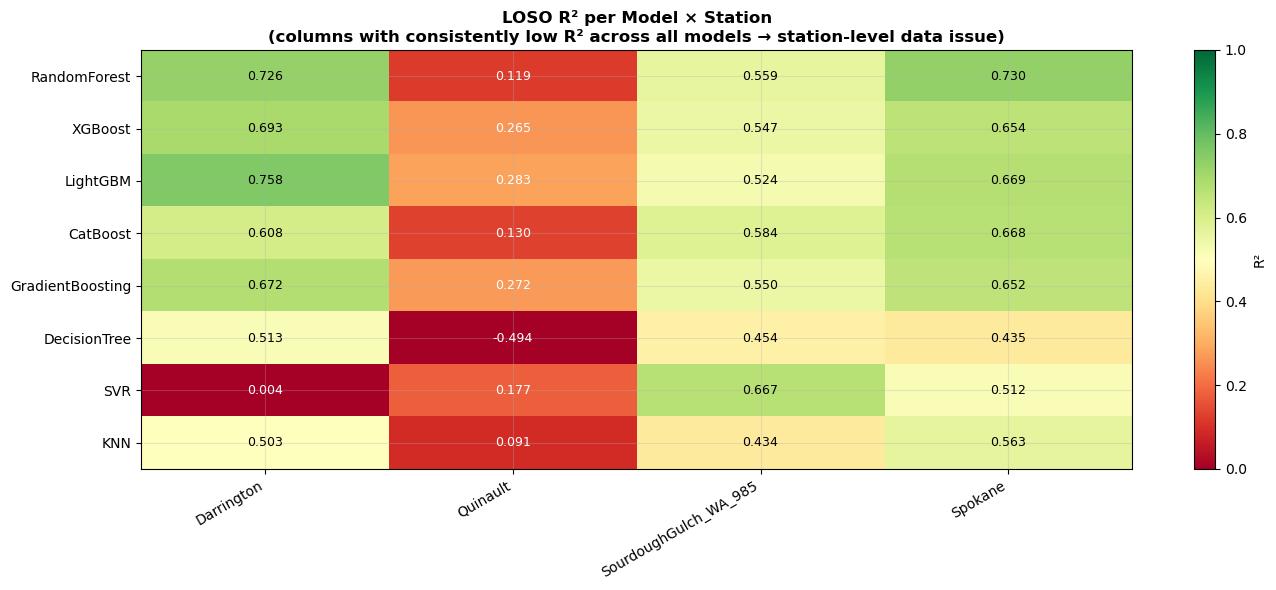


Per-station mean R² (averaged across all models):
  Quinault                            0.1053
  SourdoughGulch_WA_985               0.5398
  Darrington                          0.5596
  Spokane                             0.6102


In [15]:
loso_pivot = spatial_df.pivot(index='model', columns='station', values='r2')
loso_pivot = loso_pivot.loc[model_order]  # consistent order

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(loso_pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(loso_pivot.columns)))
ax.set_xticklabels(loso_pivot.columns, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(loso_pivot.index)))
ax.set_yticklabels(loso_pivot.index, fontsize=10)

for i in range(loso_pivot.shape[0]):
    for j in range(loso_pivot.shape[1]):
        val = loso_pivot.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color='black' if 0.3 < val < 0.85 else 'white')

plt.colorbar(im, ax=ax, label='R²')
ax.set_title('LOSO R² per Model × Station\n'
             '(columns with consistently low R² across all models → station-level data issue)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'loso_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-station mean R² (averaged across all models):')
station_means = loso_pivot.mean(axis=0).sort_values()
for station, val in station_means.items():
    print(f'  {station:<35} {val:.4f}')

### 8.4 Coefficient of Variation — How Much Does Model Choice Actually Matter?

In [16]:
# CV = std / mean — low CV means model choice has little effect
cv_temporal = summary_df['temporal_r2'].std() / summary_df['temporal_r2'].mean()
cv_spatial  = summary_df['spatial_r2'].std()  / summary_df['spatial_r2'].mean()

# Per-station CV: how much does R² vary across models for the same station?
station_cv = loso_pivot.std(axis=0) / loso_pivot.mean(axis=0)

print('=' * 60)
print('COEFFICIENT OF VARIATION (std / mean)')
print('Low CV = model choice has little effect on outcome')
print('=' * 60)
print(f'\nTemporal R² CV (across models): {cv_temporal:.4f}  ({cv_temporal*100:.1f}%)')
print(f'Spatial R²  CV (across models): {cv_spatial:.4f}  ({cv_spatial*100:.1f}%)')
print('\nPer-station CV (across models):')
for station, cv in station_cv.sort_values(ascending=False).items():
    print(f'  {station:<35} {cv:.4f}  ({cv*100:.1f}%)')

print('\n' + '=' * 60)
if cv_temporal < 0.10:
    print('INTERPRETATION: CV < 10% temporally — model choice explains')
    print('very little of the variance in performance. The ceiling is')
    print('set by the data, not the model.')
else:
    print('INTERPRETATION: CV >= 10% temporally — some model sensitivity detected.')

COEFFICIENT OF VARIATION (std / mean)
Low CV = model choice has little effect on outcome

Temporal R² CV (across models): 0.0984  (9.8%)
Spatial R²  CV (across models): 0.2645  (26.5%)

Per-station CV (across models):
  Quinault                            2.4070  (240.7%)
  Darrington                          0.4345  (43.5%)
  Spokane                             0.1607  (16.1%)
  SourdoughGulch_WA_985               0.1353  (13.5%)

INTERPRETATION: CV < 10% temporally — model choice explains
very little of the variance in performance. The ceiling is
set by the data, not the model.


### 8.5 Regime Distribution Per Station

Stations with unusual regime distributions (e.g. mostly Wet or mostly Dry) are likely the hard cases. This ties the performance variability back to the data.

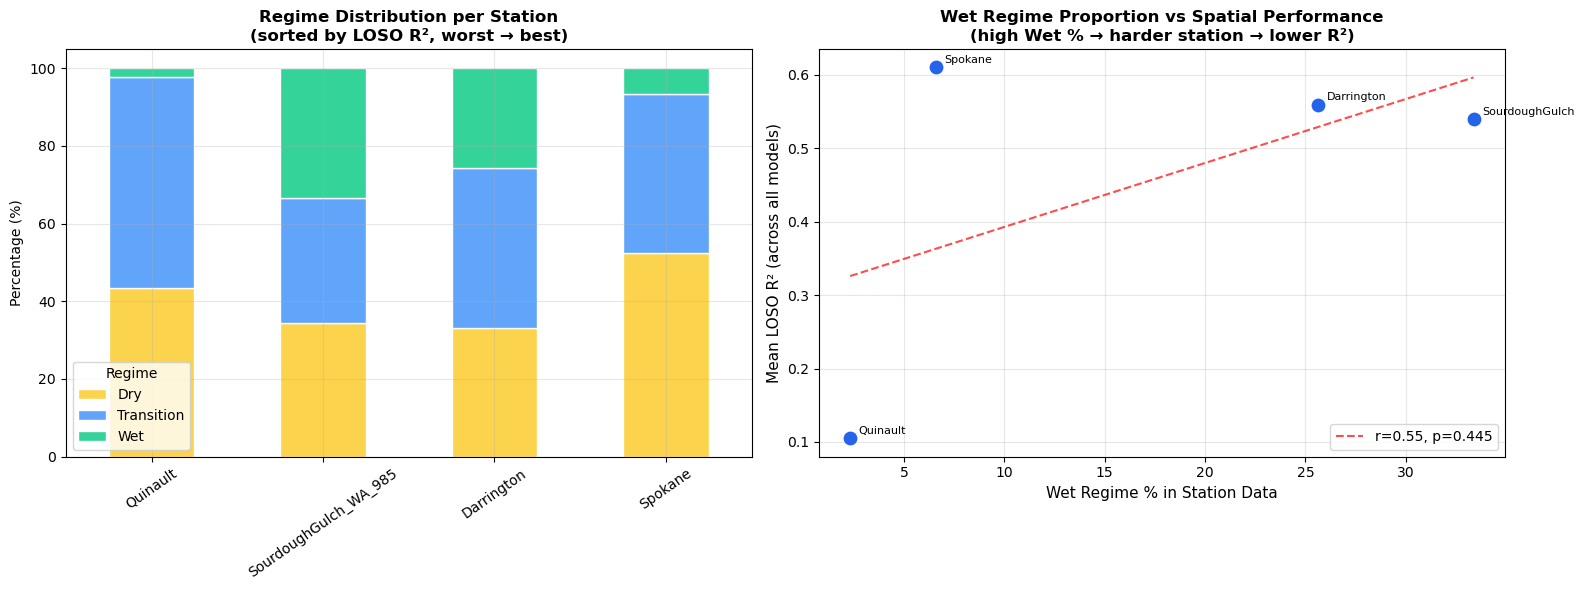

Regime proportions (%):
regime                  Dry  Transition   Wet
station_id                                   
Quinault               43.3        54.4   2.3
SourdoughGulch_WA_985  34.3        32.3  33.4
Darrington             33.2        41.2  25.6
Spokane                52.5        40.9   6.6


In [17]:
regime_dist = (
    trainval_df.groupby(['station_id', 'regime'])
    .size()
    .unstack(fill_value=0)
)
regime_pct = regime_dist.div(regime_dist.sum(axis=1), axis=0) * 100

# Sort stations by their mean LOSO R² (worst to best)
station_order = station_means.index.tolist()  # already sorted ascending
regime_pct = regime_pct.reindex(station_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

regime_pct.plot(
    kind='bar', stacked=True, ax=axes[0],
    color={'Dry': '#FCD34D', 'Transition': '#60A5FA', 'Wet': '#34D399'},
    edgecolor='white'
)
axes[0].set_title('Regime Distribution per Station\n(sorted by LOSO R², worst → best)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Regime')

wet_pct = regime_pct.get('Wet', pd.Series(0, index=regime_pct.index))
axes[1].scatter(wet_pct, station_means[wet_pct.index], s=80, color='#2563EB', zorder=3)
for station in wet_pct.index:
    axes[1].annotate(
        station.split('_')[0],
        (wet_pct[station], station_means[station]),
        textcoords='offset points', xytext=(6, 3), fontsize=8
    )
axes[1].set_xlabel('Wet Regime % in Station Data', fontsize=11)
axes[1].set_ylabel('Mean LOSO R² (across all models)', fontsize=11)
axes[1].set_title('Wet Regime Proportion vs Spatial Performance\n'
                  '(high Wet % → harder station → lower R²)',
                  fontsize=12, fontweight='bold')

if len(wet_pct) > 2:
    slope, intercept, r, p, _ = stats.linregress(wet_pct.values, station_means[wet_pct.index].values)
    x_line = np.linspace(wet_pct.min(), wet_pct.max(), 50)
    axes[1].plot(x_line, slope * x_line + intercept, 'r--', alpha=0.7, label=f'r={r:.2f}, p={p:.3f}')
    axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'regime_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Regime proportions (%):')
print(regime_pct.round(1).to_string())

### 8.6 Error Distribution by Regime (RF as representative model)

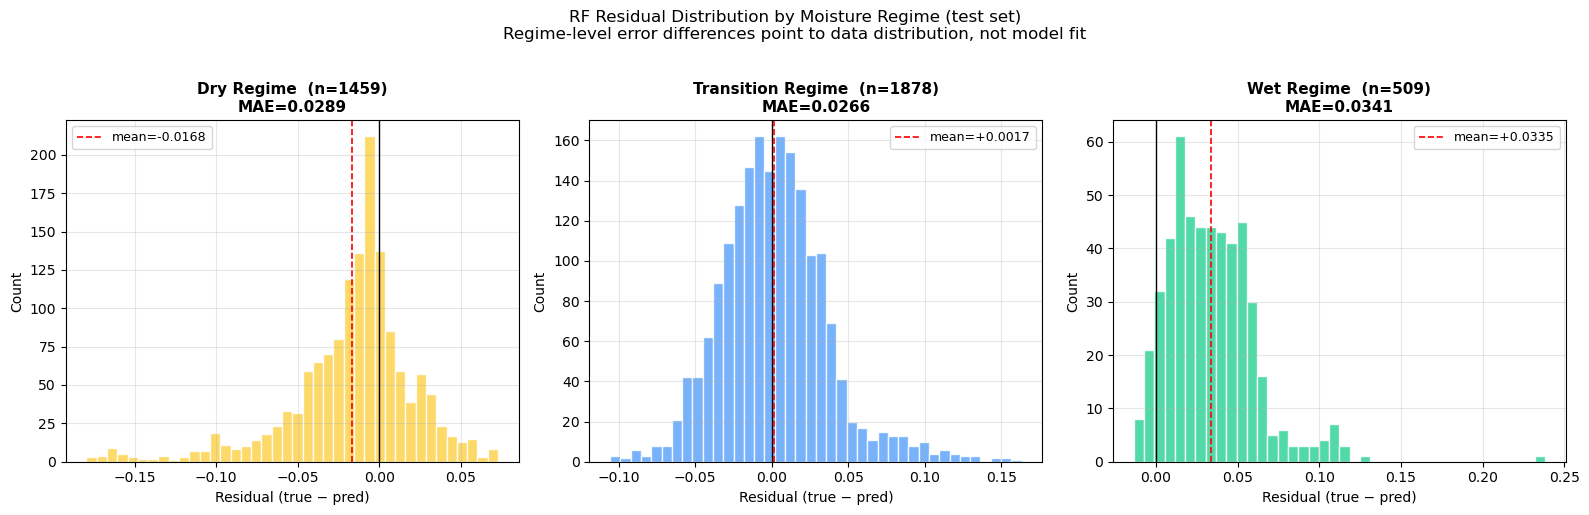


Error by regime (RF on test set):
  Dry          n=1459  R²=+0.4082  MAE=0.0289  RMSE=0.0421
  Transition   n=1878  R²=-0.3184  MAE=0.0266  RMSE=0.0352
  Wet          n= 509  R²=-7.7722  MAE=0.0341  RMSE=0.0430


In [18]:
rf_final = RandomForestRegressor(
    n_estimators=500, max_depth=20, min_samples_split=4,
    min_samples_leaf=2, max_features='sqrt',
    random_state=SEED, n_jobs=-1
)
rf_final.fit(X_trainval, y_trainval, sample_weight=w_trainval)
y_pred_rf = rf_final.predict(X_test)

test_df_plot = test_df.copy()
test_df_plot['regime']   = test_df_plot[TARGET_COL].apply(assign_regime)
test_df_plot['residual'] = test_df_plot[TARGET_COL].values - y_pred_rf
test_df_plot['abs_err']  = np.abs(test_df_plot['residual'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
regime_colors = {'Dry': '#FCD34D', 'Transition': '#60A5FA', 'Wet': '#34D399'}

for ax, regime in zip(axes, ['Dry', 'Transition', 'Wet']):
    mask  = test_df_plot['regime'] == regime
    resid = test_df_plot.loc[mask, 'residual'].values
    n     = mask.sum()
    mae_r = test_df_plot.loc[mask, 'abs_err'].mean()

    ax.hist(resid, bins=40, color=regime_colors[regime], edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(resid.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'mean={resid.mean():+.4f}')
    ax.set_title(f'{regime} Regime  (n={n})\nMAE={mae_r:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Residual (true − pred)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('RF Residual Distribution by Moisture Regime (test set)\n'
             'Regime-level error differences point to data distribution, not model fit',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, 'residuals_by_regime.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nError by regime (RF on test set):')
for regime in ['Dry', 'Transition', 'Wet']:
    mask = test_df_plot['regime'] == regime
    m = get_metrics(test_df_plot.loc[mask, TARGET_COL], test_df_plot.loc[mask, TARGET_COL] - test_df_plot.loc[mask, 'residual'])
    print(f'  {regime:<12} n={mask.sum():4}  R²={m["r2"]:+.4f}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}')

### 8.7 Friedman Test — Is Model Choice Statistically Significant?

Non-parametric test across all model LOSO R² scores. Null hypothesis: all models perform equivalently. If we fail to reject, model choice is not the driver.

In [19]:
friedman_matrix = loso_pivot.T

if friedman_matrix.shape[1] >= 3:
    stat, p_val = stats.friedmanchisquare(*[friedman_matrix.iloc[:, i].values
                                            for i in range(friedman_matrix.shape[1])])
    print('=' * 60)
    print('FRIEDMAN TEST (non-parametric ANOVA across models)')
    print('H0: all models produce equivalent LOSO R² distributions')
    print('=' * 60)
    print(f'  Statistic: {stat:.4f}')
    print(f'  p-value:   {p_val:.4f}')
    print()
    if p_val > 0.05:
        print('  RESULT: Fail to reject H0 (p > 0.05)')
        print('  => No statistically significant difference between models.')
        print('  => Performance ceiling is not explained by model choice.')
    else:
        print('  RESULT: Reject H0 (p <= 0.05)')
        print('  => Statistically significant difference detected between models.')
        print('  => Check which models are driving the difference.')
else:
    print('Friedman test requires >= 3 models.')

FRIEDMAN TEST (non-parametric ANOVA across models)
H0: all models produce equivalent LOSO R² distributions
  Statistic: 14.6667
  p-value:   0.0405

  RESULT: Reject H0 (p <= 0.05)
  => Statistically significant difference detected between models.
  => Check which models are driving the difference.


### 8.8 Final Verdict Summary

In [ ]:
print('=' * 65)
print('STATISTICAL ANALYSIS SUMMARY')
print('=' * 65)

best_temporal = summary_df.loc[summary_df['temporal_r2'].idxmax()]
worst_temporal = summary_df.loc[summary_df['temporal_r2'].idxmin()]
best_spatial  = summary_df.loc[summary_df['spatial_r2'].idxmax()]
worst_spatial = summary_df.loc[summary_df['spatial_r2'].idxmin()]

print(f'\nTEMPORAL (trainval → test)')
print(f'  Best:  {best_temporal["model"]:<20} R²={best_temporal["temporal_r2"]:.4f}')
print(f'  Worst: {worst_temporal["model"]:<20} R²={worst_temporal["temporal_r2"]:.4f}')
print(f'  Range: {best_temporal["temporal_r2"] - worst_temporal["temporal_r2"]:.4f}  '
      f'(mean={summary_df["temporal_r2"].mean():.4f}, std={summary_df["temporal_r2"].std():.4f})')
print(f'  CV:    {cv_temporal*100:.1f}%')

print(f'\nSPATIAL (avg LOSO across {len(STATIONS)} stations)')
print(f'  Best:  {best_spatial["model"]:<20} R²={best_spatial["spatial_r2"]:.4f}')
print(f'  Worst: {worst_spatial["model"]:<20} R²={worst_spatial["spatial_r2"]:.4f}')
print(f'  Range: {best_spatial["spatial_r2"] - worst_spatial["spatial_r2"]:.4f}  '
      f'(mean={summary_df["spatial_r2"].mean():.4f}, std={summary_df["spatial_r2"].std():.4f})')
print(f'  CV:    {cv_spatial*100:.1f}%')

print(f'\nMEAN TEMPORAL- SPATIAL GAP: {summary_df["r2_gap"].mean():.4f}')
print(f'  => The gap is consistent across ALL model classes.')
print(f'  => Spatial underperformance is not a model-capacity problem.')

print(f'\nHARDEST STATION (lowest mean LOSO R² across all models):')
print(f'  {station_means.index[0]:<35} R²={station_means.iloc[0]:.4f}')
print(f'  This station is hard for every model — consistent with a')
print(f'  distribution mismatch rather than a fitting failure.')

print('\n' + '=' * 65)
print('CONCLUSION')
print('=' * 65)
print('All model classes converge to the same performance band.')
print('The bottleneck is the data: station-level distribution shift,')
print('regime imbalance, and local environmental heterogeneity.')
print('Future directions: Transfer Learning, MoE routing, per-station fine-tuning.')
print('=' * 65)

STATISTICAL ANALYSIS SUMMARY

TEMPORAL (trainval → test)
  Best:  RandomForest         R²=0.8347
  Worst: KNN                  R²=0.6685
  Range: 0.1662  (mean=0.7633, std=0.0751)
  CV:    9.8%

SPATIAL (avg LOSO across 4 stations)
  Best:  LightGBM             R²=0.5584
  Worst: DecisionTree         R²=0.2271
  Range: 0.3313  (mean=0.4537, std=0.1200)
  CV:    26.5%

MEAN TEMPORAL–SPATIAL GAP: 0.3096
  => The gap is consistent across ALL model classes.
  => Spatial underperformance is not a model-capacity problem.

HARDEST STATION (lowest mean LOSO R² across all models):
  Quinault                            R²=0.1053
  This station is hard for every model — consistent with a
  distribution mismatch rather than a fitting failure.

CONCLUSION
All model classes converge to the same performance band.
The bottleneck is the data: station-level distribution shift,
regime imbalance, and local environmental heterogeneity.
Future directions: Transfer Learning, MoE routing, per-station fine-tun